# Marketing A/B Test: Does Showing an Ad Increase Conversion?

Analysis of a marketing experiment comparing conversion rates between users
exposed to an ad campaign versus a control group shown a Public Service
Announcement (PSA).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


sns.set_style("whitegrid")
from src.data_cleaning import load_data, clean_data

df = load_data("../data/raw/marketing_AB.csv")
df.shape

(588101, 7)

In [2]:
df.head()
df.info()
df = clean_data(df)
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Unnamed: 0     588101 non-null  int64
 1   user id        588101 non-null  int64
 2   test group     588101 non-null  str  
 3   converted      588101 non-null  bool 
 4   total ads      588101 non-null  int64
 5   most ads day   588101 non-null  str  
 6   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(4), str(2)
memory usage: 27.5 MB


,user id,test group,converted,total ads,most ads day,most ads hour,treatment
count,5.881010e+05,588101,588101.000000,588101.000000,588101,588101.000000,588101.000000
unique,NaN,2,NaN,NaN,7,NaN,NaN
top,NaN,ad,NaN,NaN,Friday,NaN,NaN
freq,NaN,564577,NaN,NaN,92608,NaN,NaN
mean,1.310692e+06,NaN,0.025239,24.820876,NaN,14.469061,0.960000
std,2.022260e+05,NaN,0.156850,43.715181,NaN,4.834634,0.195959
min,9.000000e+05,NaN,0.000000,1.000000,NaN,0.000000,0.000000
25%,1.143190e+06,NaN,0.000000,4.000000,NaN,11.000000,1.000000
50%,1.313725e+06,NaN,0.000000,13.000000,NaN,14.000000,1.000000
75%,1.484088e+06,NaN,0.000000,27.000000,NaN,18.000000,1.000000


## 2. Treatment Group Distribution

Before analyzing results, we check the treatment/control split. This dataset
uses an intentionally imbalanced design (~96% ad / ~4% psa), which is common
in real ad campaigns — companies avoid allocating large traffic shares to a
control group once they already have enough statistical power with a smaller one.

In [3]:

df["test group"].value_counts(normalize=True)

test group
ad     0.96
psa    0.04
Name: proportion, dtype: float64

In [4]:
df.groupby("test group")["converted"].mean()

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

## 3. Conversion Rate by Group

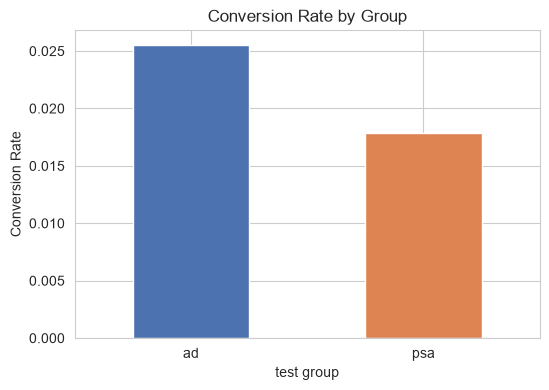

In [5]:
conversion_by_group = df.groupby("test group")["converted"].mean()

plt.figure(figsize=(6,4))
conversion_by_group.plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=0)
plt.show()

## 4. Experiment Design & Hypotheses

- **H0:** There is no difference in conversion rate between the "ad" and "psa" groups.
- **H1:** The "ad" group has a higher conversion rate than the "psa" group.
- **Test:** One-sided two-proportion z-test, since the business question is
  directional (does the ad increase conversion, not simply "is it different").
- **Significance level:** α = 0.05

In [6]:
from statsmodels.stats.proportion import proportions_ztest


converted = df.groupby("test group")["converted"].sum()
n_obs = df.groupby("test group")["converted"].count()

count = [converted["ad"],converted["psa"]]
nobs = [n_obs["ad"],n_obs["psa"]]

## 5. Hypothesis Testing

z_stat, p_value = proportions_ztest(count,nobs,alternative="larger")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.10f}")



Z-statistic: 7.3701
P-value: 0.0000000000


## 6. Effect Size, Confidence Interval & Sample Size Check

A p-value alone doesn't convey magnitude, especially with a sample this large.
We estimate the confidence interval for the difference and check how much
sample size was actually required to detect this effect.

In [7]:
from statsmodels.stats.proportion import confint_proportions_2indep

ci_low, ci_upp = confint_proportions_2indep(
    count1=converted["ad"], nobs1=n_obs["ad"],
    count2=converted["psa"], nobs2=n_obs["psa"],
    method="wald"
)
print(f"95% CI for the difference in conversion rate: ({ci_low:.4f}, {ci_upp:.4f})")

95% CI for the difference in conversion rate: (0.0060, 0.0094)


In [8]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

effect_size = proportion_effectsize(0.025547, 0.017854)
analysis = NormalIndPower()
required_n = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8, alternative="larger")
print(f"Required sample size per group to detect this effect: {required_n:.0f}")

Required sample size per group to detect this effect: 4401


## 7. Validation with Chi-Square Test

In [9]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df["test group"], df["converted"])
chi2, p_chi, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_chi:.10f}")

Chi-square statistic: 54.0058
P-value: 0.0000000000


## 8. Business Interpretation

Users exposed to the ad converted at 2.55% vs. 1.79% for the control group —
an absolute lift of 0.60–0.94 percentage points (95% CI), and statistically
significant (p < 0.0001, confirmed by both z-test and chi-square).

The experiment used ~588,000 users, while only ~4,401 per group (~8,800 total)
were needed to detect this effect with 80% power — roughly 67x more sample
than required. This suggests the test could have concluded much faster or with
a smaller traffic allocation, freeing capacity for testing additional variants.

**Recommendation:** Roll out the ad campaign — the lift is both statistically
robust and practically meaningful.

## 9. Segment-Level Heterogeneity Check

Does the effect hold consistently across day/hour segments, or is it
concentrated in a subgroup?

In [10]:
conversion_by_day = df.groupby(["most ads day", "test group"])["converted"].mean().unstack()
conversion_by_day

test group,ad,psa
most ads day,,
Friday,0.022465,0.016303
Monday,0.033241,0.022559
Saturday,0.021307,0.013996
Sunday,0.024620,0.020595
Thursday,0.021637,0.020230
Tuesday,0.030440,0.014448
Wednesday,0.025356,0.015759


In [11]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

conversion_by_day = conversion_by_day.reindex(day_order)

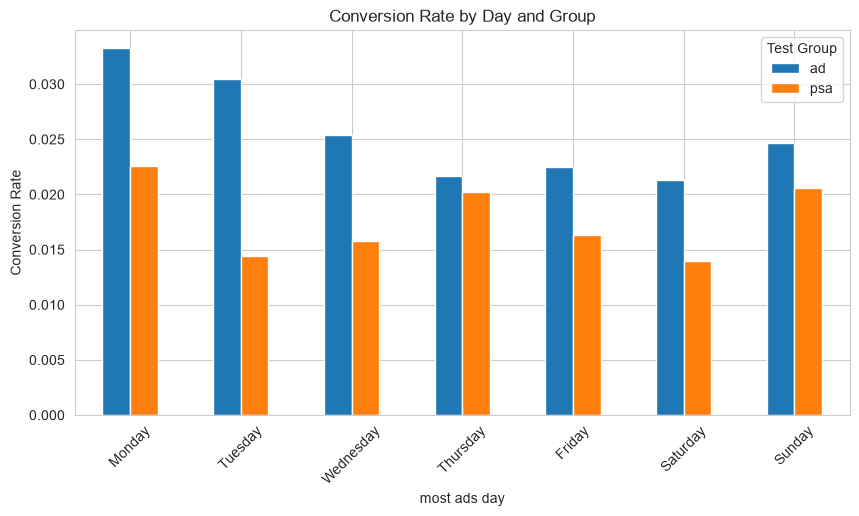

In [12]:
conversion_by_day.plot(kind="bar", figsize=(10,5))
plt.title("Conversion Rate by Day and Group")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.legend(title="Test Group")
plt.show()

In [13]:
conversion_by_hour = df.groupby(["most ads hour", "test group"])["converted"].mean().unstack()
conversion_by_hour = conversion_by_hour.sort_index()

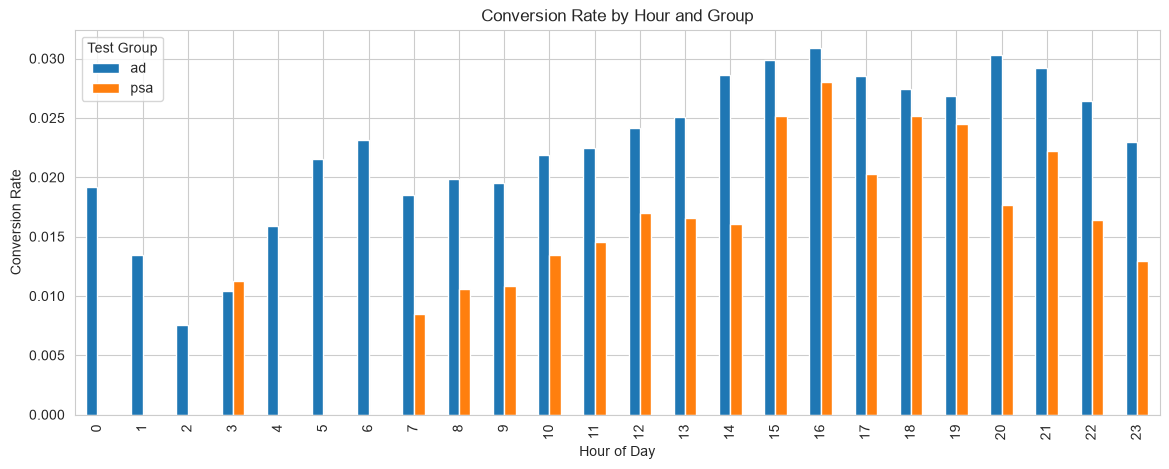

In [14]:
conversion_by_hour.plot(kind="bar", figsize=(14,5))
plt.title("Conversion Rate by Hour and Group")
plt.ylabel("Conversion Rate")
plt.xlabel("Hour of Day")
plt.legend(title="Test Group")
plt.show()

In [15]:
df.groupby(["most ads hour", "test group"]).size().unstack()

test group,ad,psa
most ads hour,,
0,5309,227
1,4615,187
2,5152,181
3,2590,89
4,694,28
5,742,23
6,1985,83
7,6168,237
8,16968,659


In [16]:
conversion_by_hour.loc[[0, 1, 2, 4, 5, 6]]

test group,ad,psa
most ads hour,,
0,0.019213,0.0
1,0.013434,0.0
2,0.007570,0.0
4,0.015850,0.0
5,0.021563,0.0
6,0.023174,0.0


### Heterogeneity Summary

- **By day:** the ad group outperforms the control group on all 7 days,
  with no reversal. Effect size varies (largest gap on Tuesday, smallest
  on Thursday/Friday), suggesting the lift is directionally robust but not
  perfectly uniform.

- **By hour:** conversion rises during afternoon/evening hours (roughly
  14:00–21:00) for both groups. The control group shows 0% conversion in
  6 low-traffic hours (0, 1, 2, 4, 5, 6) — consistent with small sample
  sizes (23–227 users) at a ~1.8% baseline rate rather than a meaningful
  pattern.
  
- **Caveat:** these are descriptive comparisons only. Running 7 (day) or 24
  (hour) separate significance tests would inflate the false-positive rate;
  a formal interaction test (or multiple-comparison correction) would be
  needed to confirm whether any specific day/hour effect is statistically
  meaningful. This is noted as a natural extension, not resolved here.

In [17]:
df["converted"].dtype
df["converted"].unique()
df["converted"] = df["converted"].astype(int)

In [18]:
import statsmodels.formula.api as smf

df["treatment"] = (df["test group"] == "ad").astype(int)

interaction_model = smf.logit(
    "converted ~ treatment * C(Q('most ads day'))",
    data=df
).fit()

print(interaction_model.summary())

Optimization terminated successfully.
         Current function value: 0.117379
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               588101
Model:                          Logit   Df Residuals:                   588087
Method:                           MLE   Df Model:                           13
Date:                Sat, 12 Sep 2026   Pseudo R-squ.:                0.003407
Time:                        16:49:46   Log-Likelihood:                -69031.
converged:                       True   LL-Null:                       -69267.
Covariance Type:            nonrobust   LLR p-value:                 1.290e-92
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                 

In [19]:
from scipy.stats import chi2

model_no_interaction = smf.logit(
    "converted ~ treatment + C(Q('most ads day'))",
    data=df
).fit()

llr_stat = 2 * (interaction_model.llf - model_no_interaction.llf)
df_diff = interaction_model.df_model - model_no_interaction.df_model
p_value = chi2.sf(llr_stat, df_diff)

print(f"LLR statistic: {llr_stat:.4f}")
print(f"Degrees of freedom: {df_diff}")
print(f"P-value: {p_value:.4f}")

Optimization terminated successfully.
         Current function value: 0.117393
         Iterations 8
LLR statistic: 16.2195
Degrees of freedom: 6.0
P-value: 0.0126


### Formal Interaction Test

- An omnibus likelihood ratio test comparing a logistic model with a
  treatment × day interaction against one without it shows significant
  evidence of heterogeneity overall (LLR = 16.22, df = 6, **p = 0.0126**) —
  the treatment effect is not identical across all days.

- However, individual day-by-day interaction coefficients do not survive a
  Bonferroni correction (adjusted α ≈ 0.0083). Tuesday came closest
  (p = 0.033 uncorrected) but does not clear the corrected threshold.
  
- **Interpretation:** there is statistically credible evidence that the ad's
  effect varies by day, but the current data cannot pinpoint which specific
  day(s) drive that variation with full confidence. A larger sample or a
  pre-registered day-specific hypothesis would be needed to isolate it.